In [1]:
import os
import numpy as np
import pandas as pd
import ast
import torch
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt 

import utils.constants as Consts
import utils.plotting as Pl
import utils.library as Lib
import utils.rerun_snapshot as RS
from utils.prune import StatPrune

# Constants + config
p = Consts.PhysicalConstants() # physical constants
o = Consts.OtherConstants() # other constants
tkwargs = {'dtype': o.dtype, 'device': o.device}
lib = Lib.Library(**tkwargs)

script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.join(os.path.dirname(script_dir))
base_path = os.path.join(project_root, "data", "rf", "pic")
PATH_TO_DATA = os.path.join(base_path, "ml_data")
full_training_path = os.path.join(base_path, "full_window", "full_window_130433_19012026")
optimized_training_path = os.path.join(base_path, "holdout_val", "holdout_val_230432_31012026")

plotting = Pl.Plotting(base_path, png_figures=False, svg_figures=True)

# Load data
data = np.load(os.path.join(PATH_TO_DATA, "mean_bulk_ccp_dataset.npz"))["profiles"]

In [2]:
# Build designs
flux_info, inputs_by_name, flux, roles = lib.make_flux_model(data, verbose=True)
adhoc_Theta, adhoc_symbols_list, adhoc_exps = lib.create_library(flux_info, inputs_by_name)
pruner = StatPrune(topk_remove=0, pruning_lmb=1e-6, verbose=True)
phys_Theta, phys_symbols_list_full, phys_exps = pruner.keep_whitelist(flux_info, adhoc_Theta, adhoc_symbols_list, adhoc_exps, roles)

scaling_consts = np.load(os.path.join(base_path, "scaling_consts.npz"))

P_all = inputs_by_name["P"][:, 0].detach().cpu().numpy()
F_all = inputs_by_name["F"][:, 0].detach().cpu().numpy()

M_total = int(phys_Theta.shape[0])

p_min = float(P_all.min())
p_max = float(P_all.max())
f_min = float(F_all.min())
f_max = float(F_all.max())

P_unique = np.unique(P_all)
F_unique = np.unique(F_all)
p_half_min = float(np.min(np.diff(np.sort(P_unique))))
f_half_min = float(np.min(np.diff(np.sort(F_unique))))

min_train = 5
min_val = 1

SST_FLOOR = RS._sst_floor_from_flux(
    flux,
    np.ones(M_total, dtype=bool),
    q=0.05,
    eps=1e-12,
)

rng0 = np.random.default_rng(1)
initial_coef_full = rng0.uniform(
    low=-1.0,
    high=1.0,
    size=len(phys_symbols_list_full),
)

Shape of library: torch.Size([188, 100, 510]) [M, N, d]
0 | 1: min=1.0, max=1.0
1 | n**(-1)*P**(-1): min=0.11883396655321121, max=225.08029174804688
2 | n**(-1)*P**(-1)*F: min=0.19640251994132996, max=73.41908264160156
3 | n**(-1): min=0.23115144670009613, max=176.45887756347656
4 | n**(-1)*F: min=0.38203492760658264, max=45.22514343261719
5 | n**(-1)*P: min=0.11583074927330017, max=228.8275146484375
6 | n**(-1)*P*F: min=0.1914389580488205, max=47.27425765991211
7 | n**(-1)*T_i**0.5*P**(-1): min=0.11869937926530838, max=1871.9351806640625
8 | n**(-1)*T_i**0.5: min=0.23088964819908142, max=1512.0400390625
9 | n**(-1)*T_i**0.5*F: min=0.3816022276878357, max=376.12591552734375
10 | n**(-1)*T_i**0.5*P: min=0.09665101021528244, max=1960.7762451171875
11 | n**(-1)*T_i*P**(-1): min=0.11856494098901749, max=15568.4033203125
12 | n**(-1)*T_i: min=0.2306281477212906, max=12956.3603515625
13 | n**(-1)*T_i*F: min=0.38117003440856934, max=3128.142578125
14 | n**(-1)*T_i*P: min=0.08064713329076767, 

In [3]:
# Helpers
def _to_numpy_int(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(np.int64)
    return np.asarray(x, dtype=np.int64)
def _parse_keep_cols(x):
    if isinstance(x, str):
        x = x.strip()
        try:
            return np.asarray(ast.literal_eval(x), dtype=np.int64)
        except Exception:
            x = x.strip("[]")
            if len(x) == 0:
                return np.asarray([], dtype=np.int64)
            return np.asarray([int(v) for v in x.split()], dtype=np.int64)
    return np.asarray(x, dtype=np.int64)
def show_trial_plots(exp_dir, tags_to_model, show_knn=True, show_parity=True):
    out = {}
    for tag, model in tags_to_model.items():
        print(f"model {model}, tag {tag}")
        out[tag] = RS.run_one_trial(
            trial_name=tag,
            exp_dir=exp_dir,
            Theta=phys_Theta,
            symbols_list=phys_symbols_list_full,
            flux=flux,
            P_all=P_all,
            F_all=F_all,
            p_min=p_min,
            p_max=p_max,
            f_min=f_min,
            f_max=f_max,
            p_half_min=p_half_min,
            f_half_min=f_half_min,
            min_train=min_train,
            min_val=min_val,
            SST_FLOOR=SST_FLOOR,
            initial_coef_full=initial_coef_full,
            scaling_consts=scaling_consts,
            show_knn=show_knn,
            show_parity=show_parity,
            write_json=False,
        )
    return out


# Full Training Range Experiment

### VIF plots

In [ ]:
Theta_tr = phys_Theta
flux_tr = flux
is_bulk_tr = np.full(Theta_tr.shape[0:2], True, dtype=bool)

X_tr, y_tr, rid_tr, sid_tr, jid_tr = lib.region_flatten(
    Theta_tr,
    is_bulk_tr,
    flux_tr,
)

n_space = int(Theta_tr.shape[1])
f_train_full = lib.train_(X_tr, y_tr, rid_tr, sid_tr, jid_tr, n_space)

pruner = StatPrune(
    topk_remove=int(0.3 * len(phys_symbols_list_full)),
    pruning_lmb=1e-6,
    verbose=False,
)

f_Xb_opt, _, keep_cols_full = pruner.run_prune(
    f_train_full=f_train_full,
    f_Xb=X_tr,
    f_symbols_list_full=phys_symbols_list_full,
)

keep_cols_full = _to_numpy_int(keep_cols_full)
keep_t_full = torch.as_tensor(keep_cols_full, dtype=torch.long, device=phys_Theta.device)

Theta_kept_full = phys_Theta.index_select(2, keep_t_full)
syms_kept_full = [phys_symbols_list_full[int(j)] for j in keep_cols_full.tolist()]

r_full = plotting.vif(
    Theta_kept_full,
    syms_kept_full,
    high=False,
    n_keep=5,
    plot_vif=False,
    plot_corr=False,
    stage="pruned_full_window",
    lollipop_plot=True,
)

vif_df_f = pd.DataFrame(
    {
        "tag": "full",
        "rank": np.arange(1, len(r_full["symbols_kept"]) + 1, dtype=int),
        "term": [str(t).replace("$", "") for t in r_full["symbols_kept"]],
        "vif": np.asarray(r_full["vif_kept"], dtype=float),
    }
)

plotting.plot_vif_heatmap(
    df_full=vif_df_f,
    mode="full",
    model_order=["full"],
    tag_to_model=None,
    show=True
)

### MOBO plots

In [ ]:
records_full = pd.read_csv(os.path.join(full_training_path, "summary_all.csv"))
df_full = pd.DataFrame(records_full)
if "iteration" in df_full.columns:
    df_full = df_full.sort_values("iteration").reset_index(drop=True)

In [ ]:
plotting.mobo_2d_pareto(
    df_full,
    x="nonzero_count",
    set_xlabel="Complexity",
    y="cv5_error",
    set_ylabel="Cross Validation",
    plot_save_name="Cv5V",
    xlim=None,
    show=True
)
plotting.mobo_2d_pareto(
    df_full,
    x="nonzero_count",
    set_xlabel="Complexity",
    y="cv5_error",
    set_ylabel="Cross Validation",
    plot_save_name="Cv5V_lim",
    xlim=[0, 20],
    show=True
)

In [ ]:
plotting.mobo_hypervolume_trace_2obj(
    df_full,
    obj1_col="cv5_error",
    obj2_col="complexity_norm",
    save_name="hypervolume_trace", 
    show=True
)

### PF performance heatmaps and parities

In [ ]:
full_tags_to_model = {
    "193_0a4f91ae" : "a", 
    "72_2206300e" : "b",
    "209_86e0afb6" : "c",
    "367_ae2cd343" : "d"
}

full_metrics = show_trial_plots(
    exp_dir=full_training_path,
    tags_to_model=full_tags_to_model,
    show_knn=True,
    show_parity=True,
)

# Optimized Training Range Experiment

### VIF plots

In [ ]:
opt_tag_to_model = {
    "294_cd141470": "a",
    "274_eeed5557": "b",
    "323_b5d4bd75": "c",
    "486_f7aa5f2e": "d",
}

summary_df = pd.read_csv(os.path.join(optimized_training_path, "summary_all.csv"))

dfs = []
for tag in opt_tag_to_model.keys():
    row = summary_df.loc[summary_df["tag"] == tag]
    if len(row) == 0:
        continue

    keep_cols = _parse_keep_cols(row.iloc[0]["keep_cols"])
    keep_t = torch.as_tensor(keep_cols, dtype=torch.long, device=phys_Theta.device)

    Theta_kept = phys_Theta.index_select(2, keep_t)
    syms_kept = [phys_symbols_list_full[int(j)] for j in keep_cols.tolist()]

    r = plotting.vif(
        Theta_kept,
        syms_kept,
        high=False,
        n_keep=5,
        plot_vif=False,
        plot_corr=False,
        stage=f"pruned_{tag}",
        lollipop_plot=True,
    )

    df_tag = pd.DataFrame(
        {
            "tag": tag,
            "rank": np.arange(1, len(r["symbols_kept"]) + 1, dtype=int),
            "term": [str(t).replace("$", "") for t in r["symbols_kept"]],
            "vif": np.asarray(r["vif_kept"], dtype=float),
        }
    )
    dfs.append(df_tag)

vif_df_s = pd.concat(dfs, ignore_index=True)

plotting.plot_vif_heatmap(
    df_opt=vif_df_s,
    mode="optimized",
    model_order=opt_tag_to_model.values(),
    tag_to_model=opt_tag_to_model,
    show=True
)

### MOBO plots

In [4]:
obj1gen_th = 1.0
obj2comp_th = 0.08
obj3val_th = 1.0

obj_cols = ["generalizability_error", "nonzero_count", "validation_error"]
obj_cols_labels = ["Generalizability", "Complexity", "Validation"]
ref = [obj1gen_th, obj2comp_th, obj3val_th]

records = pd.read_csv(os.path.join(optimized_training_path, "summary_all.csv"))
df = pd.DataFrame(records)
if "iteration" in df.columns:
    df = df.sort_values("iteration").reset_index(drop=True)

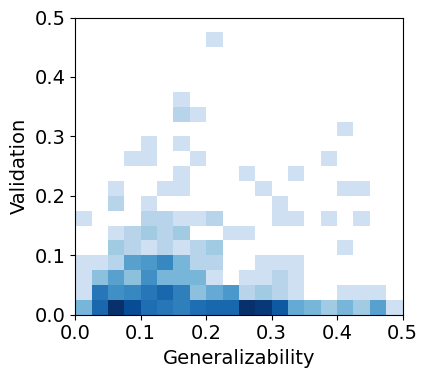

In [44]:
plotting.mobo_2d_pareto(
    df,
    y=obj_cols[2],
    set_ylabel=obj_cols_labels[2],
    x=obj_cols[0],
    set_xlabel=obj_cols_labels[0],
    plot_save_name="GvV",
    nbins_y=40,
    nbins_x=40, 
    xlim=[0, 0.5],
    ylim=[0, 0.5],
    show=True
)

In [47]:
plotting.mobo_2d_pareto(
    df,
    x=obj_cols[1],
    set_xlabel=obj_cols_labels[1],
    y=obj_cols[0],
    set_ylabel=obj_cols_labels[0],
    plot_save_name="CvG_lim",
    xlim=[0, 20],
    nbins_y=40,
    nbins_x=20, 
    # y_bin_width=0.02,
    # x_bin_width=0.78,
    # show=True
)

In [ ]:
plotting.mobo_2d_pareto(
    df,
    x=obj_cols[1],
    set_xlabel=obj_cols_labels[1],
    y=obj_cols[2],
    set_ylabel=obj_cols_labels[2],
    plot_save_name="CvV",
    xtick_cnt=15,
    xlim=None,
    show=True
)

In [46]:
plotting.mobo_2d_pareto(
    df,
    x=obj_cols[1],
    set_xlabel=obj_cols_labels[1],
    y=obj_cols[2],
    set_ylabel=obj_cols_labels[2],
    plot_save_name="CvV_lim",
    xlim=[0, 20],
    nbins_x=20,
    nbins_y=40,
    xlim_ins=[0, 10],
    ylim_ins=[0, 5e-3],
    x_bin_width_ins=1.0,
    y_bin_width_ins=0.55e-3,
    # show=True
)

In [ ]:
plotting.mobo_hypervolume_trace_3obj(
    df,
    obj_cols=["generalizability_error", "complexity_norm", "validation_error"],
    ref=ref,
    save_name="hypervolume_trace_3obj",
    sort_by_iteration=True,
    normalize=False,
    show=True
)

In [ ]:
plotting.mobo_3d_pareto(
    df,
    gen_col="generalizability_error",
    comp_col="complexity_norm",
    val_col="validation_error",
    save_name="mobo_3d_gen_comp_val",
    show=True
)

### PF performance heatmaps and parities

In [ ]:
opt_metrics = show_trial_plots(
    exp_dir=optimized_training_path,
    tags_to_model=opt_tag_to_model,
    show_knn=True,
    show_parity=True,
)

### Generalizability analysis plots

In [ ]:
def _parse_list_field(x):
    if isinstance(x, list):
        return x
    if isinstance(x, (np.ndarray, tuple)):
        return list(x)
    if not isinstance(x, str):
        return list(x)
    s = x.strip()
    if s == "":
        return []
    return ast.literal_eval(s)

def _window_center(row):
    pc = 0.5 * (float(row["p_lo_eff"]) + float(row["p_hi_eff"]))
    fc = 0.5 * (float(row["f_lo_eff"]) + float(row["f_hi_eff"]))
    return pc, fc

def _vif_summaries(plotter, Theta_kept):
    out = plotter._compute_vif_values(Theta_kept)
    vif = np.asarray(out["vif_vals"], dtype=float)
    logv = np.log10(vif)
    logv = logv[np.isfinite(logv)]

    if logv.size == 0:
        return {
            "s_med": np.nan,
            "s_p90": np.nan,
            "s_max": np.nan,
            "frac_lt_2": np.nan,
        }

    return {
        "s_med": float(np.median(logv)),
        "s_p90": float(np.quantile(logv, 0.9)),
        "s_max": float(np.max(logv)),
        "frac_lt_2": float(np.mean(logv < 2.0)),
    }

tags_sel = list(opt_tag_to_model.keys())

rows_out = []
for _, row in summary_df.iterrows():
    train_idx = np.asarray(_parse_list_field(row["train_idx"]), dtype=np.int64)
    keep_cols = np.asarray(_parse_list_field(row["keep_cols"]), dtype=np.int64)

    if train_idx.size == 0 or keep_cols.size == 0:
        continue

    tr_idx_t = torch.as_tensor(train_idx, dtype=torch.long, device=phys_Theta.device)
    kc_t = torch.as_tensor(keep_cols, dtype=torch.long, device=phys_Theta.device)

    Theta_tr = phys_Theta.index_select(0, tr_idx_t)
    Theta_kept = Theta_tr.index_select(2, kc_t)

    summ = _vif_summaries(plotting, Theta_kept)
    pc, fc = _window_center(row)

    rows_out.append({
        "tag": str(row["tag"]),
        "p_c_eff": pc,
        "f_c_eff": fc,
        "generalizability_error": float(row["generalizability_error"]),
        "validation_error": float(row["validation_error"]),
        "s_med": summ["s_med"],
        "s_p90": summ["s_p90"],
        "s_max": summ["s_max"],
        "frac_lt_2": summ["frac_lt_2"],
        "p_lo_eff": float(row["p_lo_eff"]),
        "p_hi_eff": float(row["p_hi_eff"]),
        "f_lo_eff": float(row["f_lo_eff"]),
        "f_hi_eff": float(row["f_hi_eff"]),
        "train_idx": train_idx,
        "keep_cols": keep_cols,
        "nonzero_count": row["nonzero_count"],
        "complexity_norm": row["complexity_norm"],
    })

ds = pd.DataFrame(rows_out)
ds = ds[np.isfinite(ds["s_med"]) & np.isfinite(ds["generalizability_error"])].copy()
sel = ds[ds["tag"].isin(tags_sel)].copy()

In [ ]:
fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.tick_params(labelsize=16)
font_size = 16
sc = ax.scatter(
    ds["p_c_eff"].to_numpy() * p.mean_pressure,
    ds["f_c_eff"].to_numpy() * p.mean_frequency,
    c=ds["s_med"].to_numpy(),
    s=65,
    alpha=1.0,
    edgecolors="none",
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"Median $\log_{10}(\mathrm{VIF})$", fontsize=font_size)
cbar.ax.tick_params(labelsize=font_size)

ax.scatter(
    sel["p_c_eff"].to_numpy() * p.mean_pressure,
    sel["f_c_eff"].to_numpy() * p.mean_frequency,
    c=sel["s_med"].to_numpy(),
    cmap=sc.cmap,
    norm=sc.norm,
    s=140,
    marker="X",
    alpha=1.0,
    edgecolors="#ff0000ff",
    zorder=4,
)

for _, rr in sel.iterrows():
    lab = opt_tag_to_model.get(rr["tag"], rr["tag"])
    ax.annotate(
        lab,
        (rr["p_c_eff"] * p.mean_pressure, rr["f_c_eff"] * p.mean_frequency),
        xytext=(-6, 3),
        textcoords="offset points",
        fontsize=font_size,
        color="#050303ff",
        ha="right",
        va="bottom",
        zorder=5,
        fontweight="bold",
    )

ax.set_xlabel("Pressure [mTorr]", fontsize=font_size)
ax.set_ylabel("Frequency [MHz]", fontsize=font_size)

fig.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5.3, 4.7))

ax.scatter(
    ds["s_med"].to_numpy(),
    ds["generalizability_error"].to_numpy(),
    s=65,
    alpha=0.5,
    edgecolors="none",
)

ax.scatter(
    sel["s_med"].to_numpy(),
    sel["generalizability_error"].to_numpy(),
    s=145,
    c="#ff0000ff",
    alpha=1.0,
    edgecolors="none",
    zorder=3,
    marker="X",
)

for _, rr in sel.iterrows():
    ax.text(
        rr["s_med"],
        rr["generalizability_error"],
        opt_tag_to_model.get(rr["tag"], rr["tag"]),
        fontsize=font_size, fontweight="bold",
    )

ax.set_xlabel(r"Median $\log_{10}(\mathrm{VIF})$", fontsize=font_size)
ax.set_ylabel("Generalizability", fontsize=font_size)
ax.tick_params(axis="both", labelsize=font_size)

fig.tight_layout()
plt.show()

# Both VIF experiments

In [ ]:
# both together
plotting.plot_vif_heatmap(
    df_full=vif_df_f,
    df_opt=vif_df_s,
    mode="both",
    model_order=["full", "a", "b", "c", "d"],
    tag_to_model=opt_tag_to_model,
    show=True
    )